In [6]:
%pip install nltk wordcloud kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print(path)

100%|██████████| 25.7M/25.7M [00:10<00:00, 2.66MB/s]

Extracting files...


C:\Users\Tharu\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [9]:
import os

csv_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(csv_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df.info()

df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [11]:
neutral_reviews = [
    "The movie was okay and average.",
    "The acting was fine but nothing special.",
    "It was neither good nor bad.",
    "Average storyline with decent performances.",
    "The film was watchable.",
    "Nothing impressive but not disappointing.",
    "The movie had both strengths and weaknesses.",
    "Overall it was acceptable.",
    "The music was okay.",
    "An average experience."
]*500

neutral_df = pd.DataFrame({
    "review": neutral_reviews,
    "sentiment":"neutral"
})

df = pd.concat([df, neutral_df], ignore_index=True)

df['sentiment'].value_counts()


sentiment
positive    25000
negative    25000
neutral      5000
Name: count, dtype: int64

In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [13]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [16]:
pred = model.predict(X_test)


In [17]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.901090909090909


In [18]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4984
     neutral       1.00      1.00      1.00      1013
    positive       0.88      0.90      0.89      5003

    accuracy                           0.90     11000
   macro avg       0.93      0.93      0.93     11000
weighted avg       0.90      0.90      0.90     11000



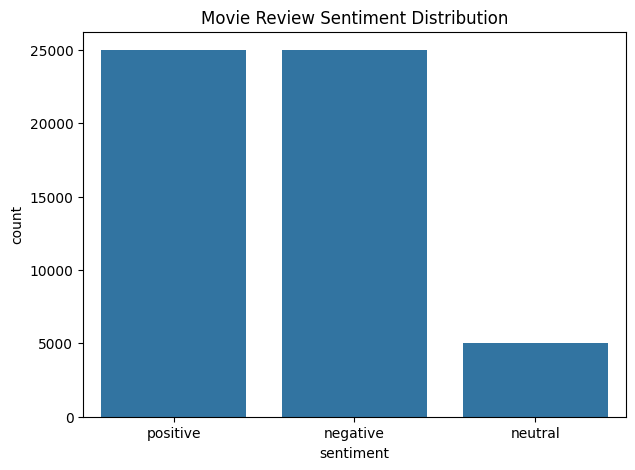

In [19]:
plt.figure(figsize=(7,5))

sns.countplot(x=df['sentiment'])

plt.title("Movie Review Sentiment Distribution")

plt.show()

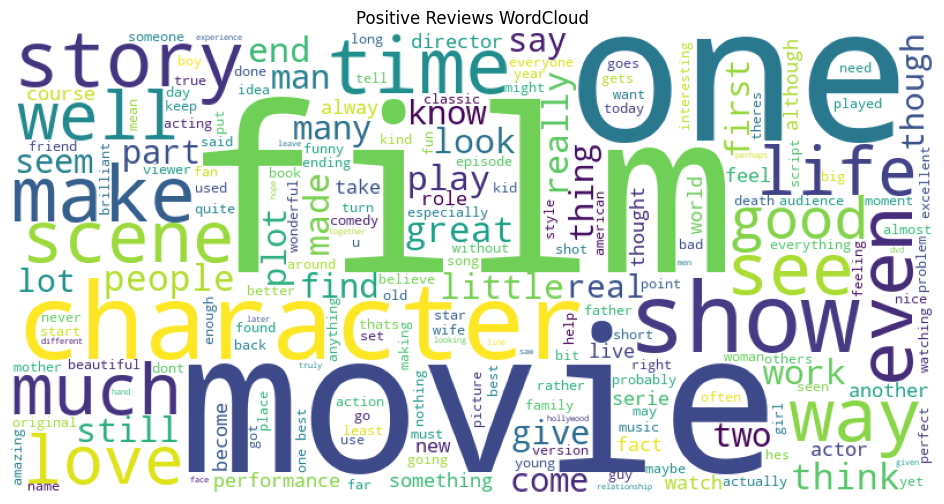

In [20]:
positive = " ".join(df[df.sentiment=="positive"]['clean_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Positive Reviews WordCloud")

plt.show()

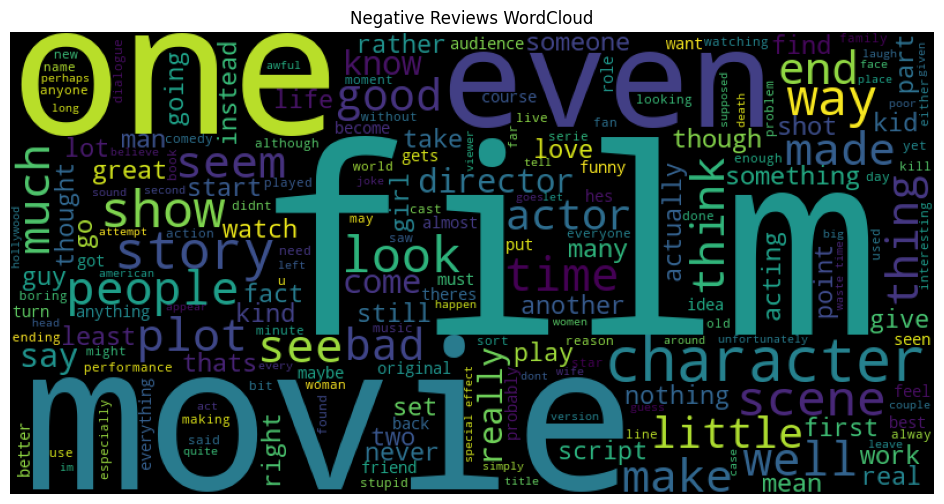

In [21]:
negative = " ".join(df[df.sentiment=="negative"]['clean_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Negative Reviews WordCloud")

plt.show()

In [22]:
review = [
    "The movie was fantastic with brilliant acting.",
    "Worst movie ever made.",
    "The film was average and watchable."
]

review_clean = [clean_text(i) for i in review]

review_vector = tfidf.transform(review_clean)

prediction = model.predict(review_vector)

for r,p in zip(review,prediction):
    print(r)
    print("Prediction:",p)
    print()

The movie was fantastic with brilliant acting.
Prediction: positive

Worst movie ever made.
Prediction: negative

The film was average and watchable.
Prediction: neutral

